# クラスタリング（Clustering） - データの自動グループ分け

ラベルなしのデータを自動でグループ分けします。  
ここでは **K-Means** を使い、アイリスデータを教師なしでクラスタリングします。

| ステップ | 内容 |
|----------|------|
| 1 | データの読み込み・確認 |
| 2 | 最適なクラスタ数を探す（エルボー法） |
| 3 | K-Means でクラスタリング |
| 4 | 可視化 |
| 5 | 正解ラベルとの比較 |

## 1. データの読み込み・確認

クラスタリングは**教師なし学習**なので、ラベル（y）は使いません。

In [1]:
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
import pandas as pd

iris = load_iris()
X = iris.data
y_true = iris.target  # 比較用に保持（学習には使わない）

# 標準化
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

df = pd.DataFrame(X, columns=iris.feature_names)
print("データ形状:", X.shape)
df.head()

データ形状: (150, 4)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


## 2. 最適なクラスタ数を探す（エルボー法）

クラスタ数 k を変えながら誤差（慣性）を計算し、  
グラフが「肘（エルボー）」のように曲がった点が最適な k です。

/tmp/ipykernel_15380/1275259654.py:19: UserWarning: Glyph 12463 (\N{KATAKANA LETTER KU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_15380/1275259654.py:19: UserWarning: Glyph 12521 (\N{KATAKANA LETTER RA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_15380/1275259654.py:19: UserWarning: Glyph 12473 (\N{KATAKANA LETTER SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_15380/1275259654.py:19: UserWarning: Glyph 12479 (\N{KATAKANA LETTER TA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_15380/1275259654.py:19: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_15380/1275259654.py:19: UserWarning: Glyph 24931 (\N{CJK UNIFIED IDEOGRAPH-6163}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_15380/1275259654.py:19: UserWarning: Glyph 24615 (\N{CJK UNIFIED IDEOGRAPH-6027}) missing from font(s) De

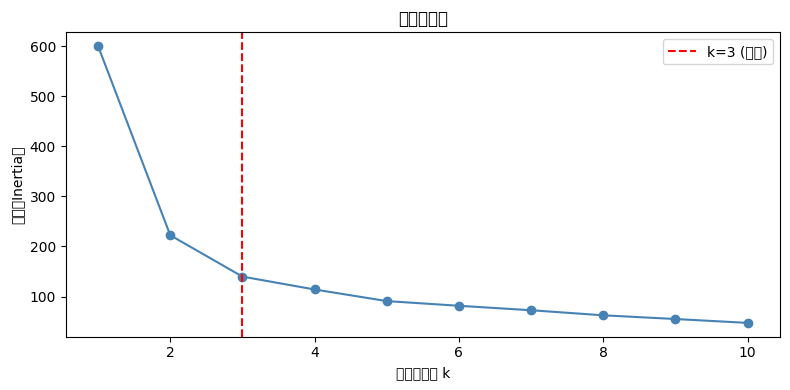

In [2]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertias = []
k_range = range(1, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(k_range, inertias, marker='o', color='steelblue')
plt.axvline(3, color='red', linestyle='--', label='k=3 (最適)')
plt.xlabel("クラスタ数 k")
plt.ylabel("慣性（Inertia）")
plt.title("エルボー法")
plt.legend()
plt.tight_layout()
plt.show()

## 3. K-Means でクラスタリング（k=3）

In [3]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans.fit(X_scaled)
labels = kmeans.labels_

print("クラスタラベル（先頭20件）:", labels[:20])
print("各クラスタの件数:")
for i in range(3):
    print(f"  クラスタ {i}: {(labels == i).sum()} 件")

クラスタラベル（先頭20件）: [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
各クラスタの件数:
  クラスタ 0: 53 件
  クラスタ 1: 50 件
  クラスタ 2: 47 件


## 4. 可視化

/tmp/ipykernel_15380/3278487524.py:30: UserWarning: Glyph 27161 (\N{CJK UNIFIED IDEOGRAPH-6A19}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_15380/3278487524.py:30: UserWarning: Glyph 28310 (\N{CJK UNIFIED IDEOGRAPH-6E96}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_15380/3278487524.py:30: UserWarning: Glyph 21270 (\N{CJK UNIFIED IDEOGRAPH-5316}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_15380/3278487524.py:30: UserWarning: Glyph 12463 (\N{KATAKANA LETTER KU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_15380/3278487524.py:30: UserWarning: Glyph 12521 (\N{KATAKANA LETTER RA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_15380/3278487524.py:30: UserWarning: Glyph 12473 (\N{KATAKANA LETTER SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_15380/3278487524.py:30: UserWarning: Glyph 12479 (\N{KATAKANA LETTER TA}) missing from font(s) De

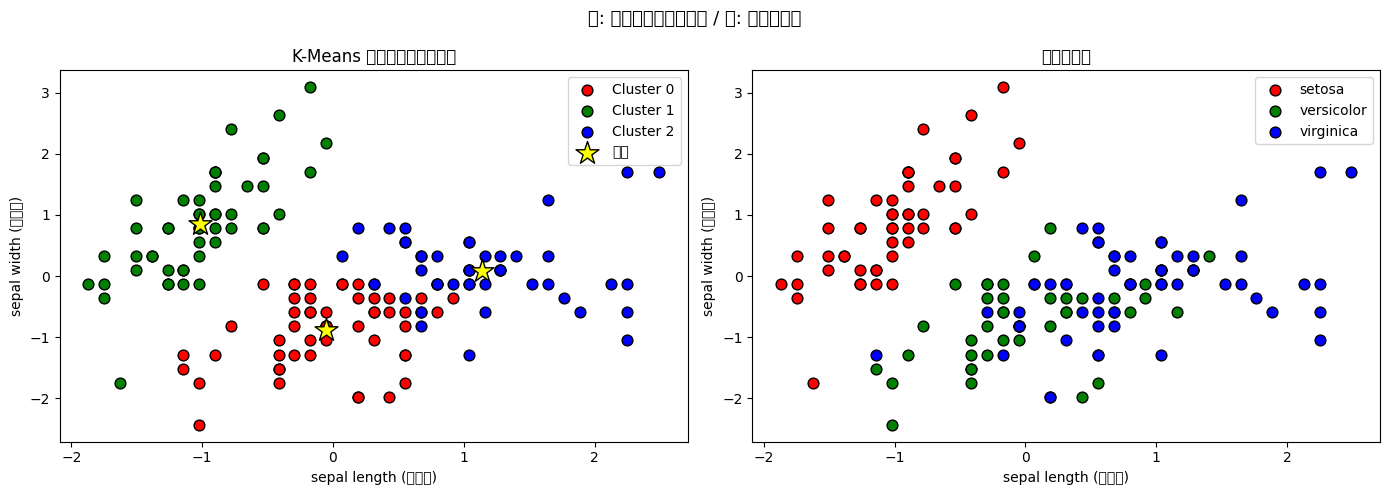

In [4]:
import numpy as np

colors = ['red', 'green', 'blue']
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# クラスタリング結果
for i, color in enumerate(colors):
    idx = np.where(labels == i)
    axes[0].scatter(X_scaled[idx, 0], X_scaled[idx, 1],
                    color=color, label=f'Cluster {i}', edgecolors='k', s=60)
centers = kmeans.cluster_centers_
axes[0].scatter(centers[:, 0], centers[:, 1],
                marker='*', s=300, color='yellow', edgecolors='black', zorder=5, label='重心')
axes[0].set_title("K-Means クラスタリング結果")
axes[0].legend()

# 正解ラベル
for i, color in enumerate(colors):
    idx = np.where(y_true == i)
    axes[1].scatter(X_scaled[idx, 0], X_scaled[idx, 1],
                    color=color, label=iris.target_names[i], edgecolors='k', s=60)
axes[1].set_title("正解ラベル")
axes[1].legend()

for ax in axes:
    ax.set_xlabel("sepal length (標準化)")
    ax.set_ylabel("sepal width (標準化)")

plt.suptitle("左: クラスタリング結果 / 右: 正解ラベル", fontsize=13)
plt.tight_layout()
plt.show()

## 5. 正解ラベルとの比較（シルエットスコア）

シルエットスコアはクラスタの凝集度・分離度を示します。  
**-1〜1 の範囲で、1 に近いほど良いクラスタリング**です。

In [5]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X_scaled, labels)
print(f"シルエットスコア: {score:.4f}")

シルエットスコア: 0.4599
